In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("IMDB Dataset.csv")

# Basic shape and columns
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())


Shape: (50000, 2)

Columns: ['review', 'sentiment']


In [2]:
# Head
print("\nSample Records:")
print(df.head(10))


Sample Records:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
5  Probably my all-time favorite movie, a story o...  positive
6  I sure would like to see a resurrection of a u...  positive
7  This show was an amazing, fresh & innovative i...  negative
8  Encouraged by the positive comments about this...  negative
9  If you like original gut wrenching laughter yo...  positive


In [3]:
# Class distribution
print("\nClass Distribution:")
print(df['sentiment'].value_counts())



Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
# Check for missing values
print("\nMissing Values:")
print(df.isna().sum())



Missing Values:
review       0
sentiment    0
dtype: int64


In [5]:

# -------------------------------------------------------------
# Text preprocessing: cleaning and normalising the reviews
# -------------------------------------------------------------
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")

# Prepare stopword list and lemmatiser
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

#  Preprocessing function: lowercase, remove HTML, digits,
#  punctuation, stopwords, and apply lemmatisation
def preprocess_text(text):
#  lowercase
    text = text.lower()
# remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
# remove digits
    text = re.sub(r"\d+", " ", text)
# remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation)) 
 # remove extra whitespace   
    text = re.sub(r"\s+", " ", text).strip()
# tokenisation
    tokens = text.split()
# remove stopwords and lemmatise
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words]
    return " ".join(tokens)
# join back to a single string
    return " ".join(tokens)

# Apply preprocessing to create a new column
df["clean_review"] = df["review"].apply(preprocess_text)


# Quick preview to confirm that the new column exists
# Table with original and cleaned text
df_preview = df[['review', 'clean_review']].head().copy()
df_preview['review'] = df_preview['review'].str[:120] + '...'
df_preview['clean_review'] = df_preview['clean_review'].str[:120] + '...'

df_preview.style.set_properties(**{
    'text-align': 'left'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
])


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mjava\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mjava\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,review,clean_review
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this...",one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinchi...
1,A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives...,wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting sens...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and...",thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lighthearted comedy plot si...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting al...,basically there family little boy jake think there zombie closet parent fighting time movie slower soap opera suddenly j...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait ...",petter matteis love time money visually stunning film watch mr mattei offer u vivid portrait human relation movie seems ...


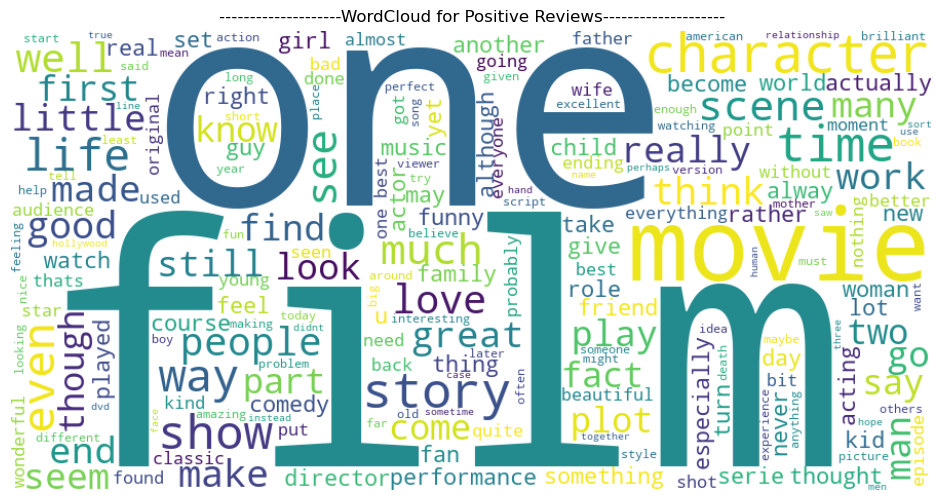

In [6]:

# -------------------------------------------------------------
# WordClouds and sample preview for positive and negative reviews
# -------------------------------------------------------------
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# WordCloud for positive reviews
positive_text = " ".join(df[df["sentiment"] == "positive"]["clean_review"])
wc_pos = WordCloud(width=900, height=450, background_color="white").generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("--------------------WordCloud for Positive Reviews--------------------")
plt.show()


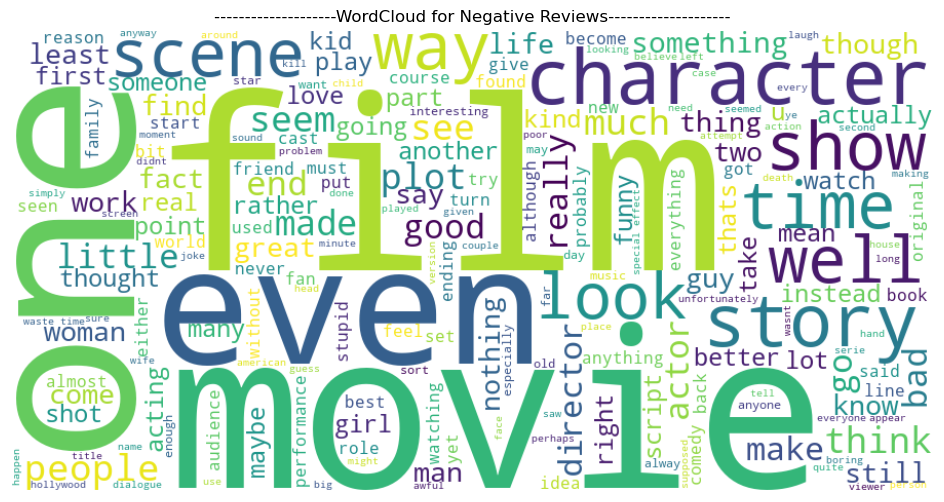

In [7]:
# WordCloud for negative reviews
negative_text = " ".join(df[df["sentiment"] == "negative"]["clean_review"])
wc_neg = WordCloud(width=900, height=450, background_color="white").generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("--------------------WordCloud for Negative Reviews--------------------")
plt.show()

In [8]:

# Table with original and cleaned text
df_preview = df[['review', 'clean_review']].head(5).copy()
df_preview['review'] = df_preview['review'].str[:120] + '...'
df_preview['clean_review'] = df_preview['clean_review'].str[:120] + '...'

df_preview.style.set_properties(**{
    'text-align': 'left'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
])

,review,clean_review
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this...",one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinchi...
1,A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives...,wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting sens...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and...",thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lighthearted comedy plot si...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting al...,basically there family little boy jake think there zombie closet parent fighting time movie slower soap opera suddenly j...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait ...",petter matteis love time money visually stunning film watch mr mattei offer u vivid portrait human relation movie seems ...


In [9]:
# -------------------------------------------------------------
# TF-IDF vectorisation and Logistic Regression classifier
#  -------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features and labels
X = df["clean_review"]
y = df["sentiment"]

# Train–test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectoriser with unigrams and bigrams
vectoriser = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_vec = vectoriser.fit_transform(X_train)
X_test_vec = vectoriser.transform(X_test)

# Logistic Regression model
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train_vec, y_train)

#  Predictions and evaluation
y_pred = model.predict(X_test_vec)

print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Test Set Accuracy: 0.8958

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


Confusion Matrix:
[[4412  588]
 [ 454 4546]]
